Cargando datos reales desde keywords_expanded.csv...
Total registros reales para entrenar: 324
Categorías encontradas: ['Sales', 'Marketing', 'Product', 'Engineering', 'Customer Success', 'HR', 'Finance', 'Data', 'Operations', 'Legal', 'IT']
Entrenando XGBoost con datos REALES...
🎯 Accuracy con datos reales: 0.98


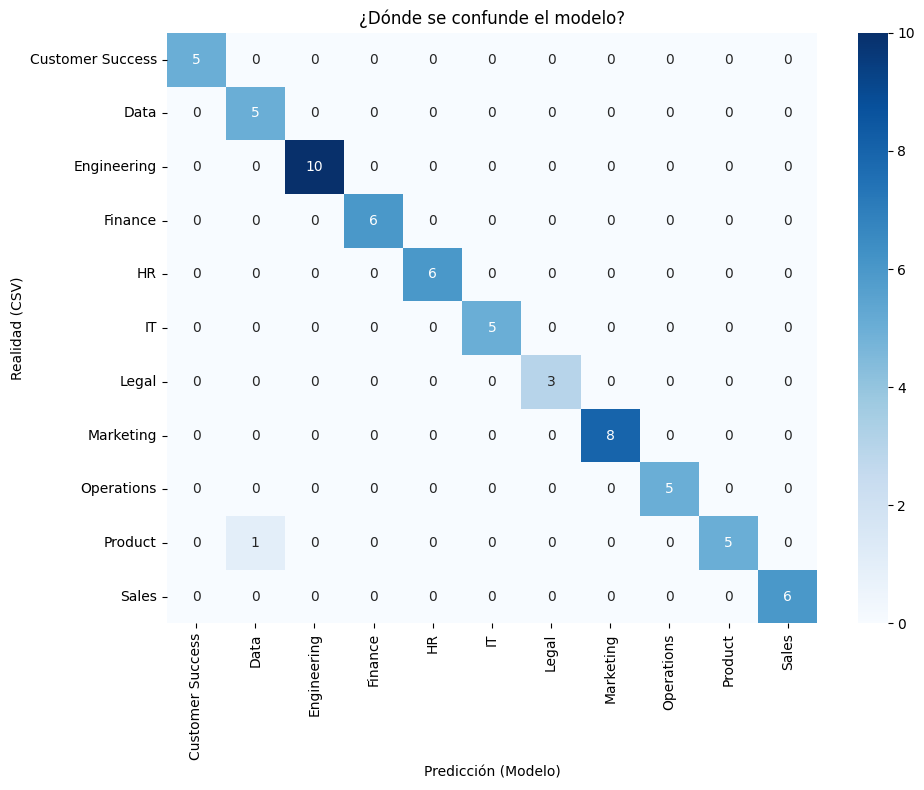


MODO 1: Clasificación de un CV individual CON GRÁFICAS

📄 Analizando CV: CV_R.pdf

📝 Texto extraído (primeros 300 caracteres):
Ruben Garrido Hidalgo
Data Analyst specialized in Machine Learning
rubengh2002@gmail.com +34 684 027 825 linkedIn/Rubén_Garrido
As a recent Mathematics graduate with a strong specialization in Data Analysis and Machine Learning, I
am actively seeking a Junior Data Analyst position to apply my techni...

🎯 RESULTADOS DE CLASIFICACIÓN:
------------------------------------------------------------

✅ DEPARTAMENTO RECOMENDADO: Data
   Confianza: 80.5%

📊 Top 5 categorías más probables:
1. Data                       80.5% ████████████████████████████████████████
2. Finance                    17.3% ████████
3. Marketing                   0.7% 
4. IT                          0.5% 
5. Engineering                 0.4% 
✅ Gráfica combinada guardada en: clasificacion_CV_R.png


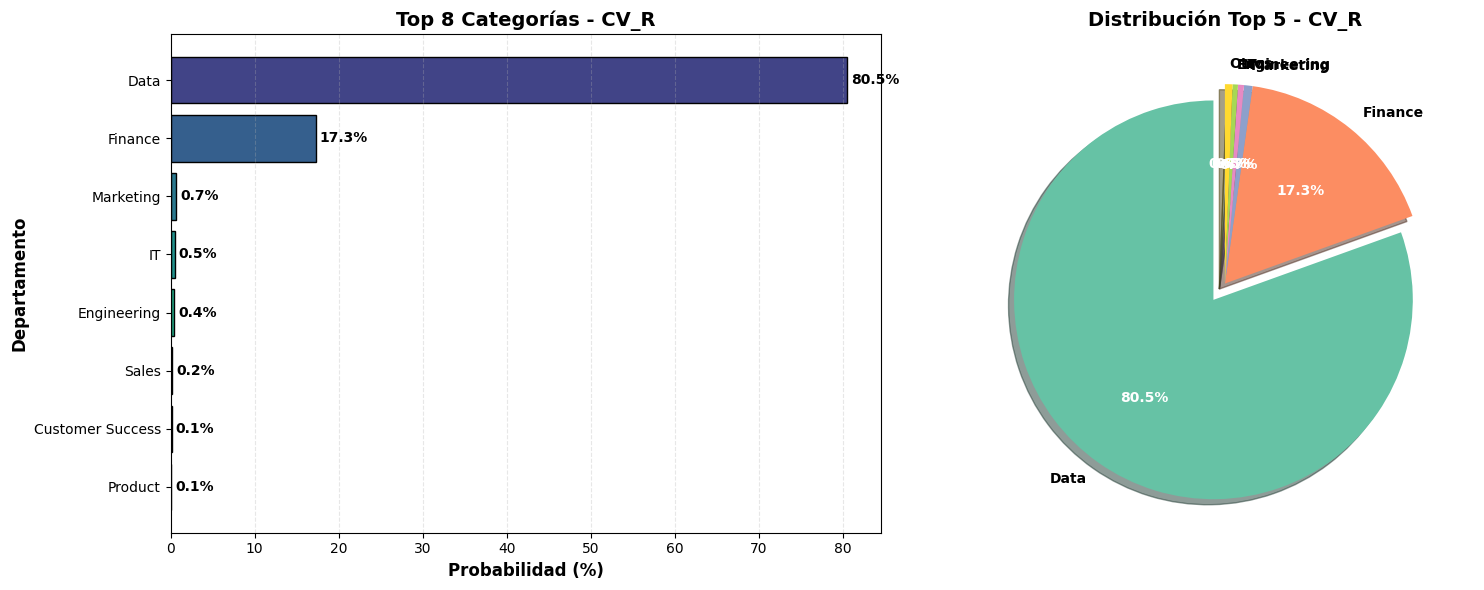

In [1]:
import pandas as pd
import numpy as np
import pdfplumber
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import os

# --- CONFIGURE PATHS ---
BASE_DIR = os.path.abspath('') 
CSV_PATH = os.path.join(BASE_DIR, 'keywords_expanded.csv')

# ===========================================================
# 1️⃣ CARGAR Y PREPARAR DATOS REALES
# ===========================================================

def load_real_training_data(csv_path):
    """Carga keywords_expanded.csv y construye textos reales para entrenamiento."""
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found at: {csv_path}")

    df = pd.read_csv(csv_path)

    print("Cargando datos reales desde keywords_expanded.csv...")

    # Crear texto combinado por fila
    df['text'] = (
        df['Role'].fillna('') + " " +
        df['Keywords'].fillna('') + " " +
        df['Skills'].fillna('') + " " +
        df['Tools'].fillna('')
    )

    df['text'] = df['text'].str.replace(',', ' ').str.replace('|', ' ')

    # Nos quedamos solo con lo necesario para el modelo
    df_train = df[['text', 'Category']].rename(columns={'Category': 'label'})

    print(f"Total registros reales para entrenar: {len(df_train)}")
    print(f"Categorías encontradas: {df_train['label'].unique().tolist()}")

    return df_train

# ===========================================================
# 2️⃣ ENTRENAR MODELO CON DATOS REALES
# ===========================================================

def train_xgboost_model(df_train):
    print("Entrenando XGBoost con datos REALES...")

    # Vectorización TF-IDF
    vectorizer = TfidfVectorizer(
        max_features=2000,
        stop_words='english',
        ngram_range=(1,2)
    )

    X = vectorizer.fit_transform(df_train['text'])

    # Encode labels
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df_train['label'])

    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Modelo XGBoost multi-clase
    clf = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(label_encoder.classes_),
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    )

    clf.fit(X_train, y_train)

    # Evaluación rápida
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"🎯 Accuracy con datos reales: {acc:.2f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel('Predicción (Modelo)')
    plt.ylabel('Realidad (CSV)')
    plt.title('¿Dónde se confunde el modelo?')
    plt.tight_layout()
    plt.show()

    return clf, vectorizer, label_encoder

# ===========================================================
# 3️⃣ EXTRAER TEXTO DE PDF
# ===========================================================

def extract_text_from_pdf(pdf_path):
    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"PDF not found: {pdf_path}")

    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            extract = page.extract_text()
            if extract:
                text += extract + "\n"
    return text

# ===========================================================
# 4️⃣ PREDICCIÓN DE DEPARTAMENTO
# ===========================================================

def predict_probabilities(model, vectorizer, label_encoder, text):
    text_vec = vectorizer.transform([text])
    probs = model.predict_proba(text_vec)[0]

    results = []
    for i, prob in enumerate(probs):
        category = label_encoder.inverse_transform([i])[0]
        results.append((category, prob))

    results.sort(key=lambda x: x[1], reverse=True)
    return results

# ===========================================================
# 5️⃣ VISUALIZACIÓN DE PREDICCIONES
# ===========================================================

def plot_predictions(results, title="Clasificación de CV", top_n=10, save_path=None):
    """Dibuja una gráfica de barras horizontales con las probabilidades."""
    top_results = results[:top_n]
    categories = [cat for cat, _ in top_results]
    probabilities = [prob * 100 for _, prob in top_results]
    
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(probabilities)))
    bars = ax.barh(categories, probabilities, color=colors, edgecolor='black', linewidth=1.2)
    
    for i, (bar, prob) in enumerate(zip(bars, probabilities)):
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{prob:.1f}%', 
                ha='left', va='center', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Probabilidad (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Departamento', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlim(0, max(probabilities) * 1.15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfica guardada en: {save_path}")
    
    plt.show()

def plot_predictions_pie(results, title="Distribución de Probabilidades", top_n=5, save_path=None):
    """Dibuja un gráfico de pastel con las top categorías."""
    top_results = results[:top_n]
    other_prob = sum([prob for _, prob in results[top_n:]])
    
    categories = [cat for cat, _ in top_results]
    probabilities = [prob * 100 for _, prob in top_results]
    
    if other_prob > 0:
        categories.append('Otros')
        probabilities.append(other_prob * 100)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.Set3(range(len(categories)))
    explode = [0.1] + [0] * (len(categories) - 1)
    
    wedges, texts, autotexts = ax.pie(
        probabilities, 
        labels=categories,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 11, 'fontweight': 'bold'}
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfica guardada en: {save_path}")
    
    plt.show()

def plot_predictions_combined(results, cv_name="CV", save_path=None):
    """Crea una visualización combinada con barras y pastel."""
    fig = plt.figure(figsize=(16, 6))
    
    # --- SUBPLOT 1: Barras horizontales ---
    ax1 = plt.subplot(1, 2, 1)
    
    top_results = results[:8]
    categories = [cat for cat, _ in top_results]
    probabilities = [prob * 100 for _, prob in top_results]
    
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(probabilities)))
    bars = ax1.barh(categories, probabilities, color=colors, edgecolor='black', linewidth=1)
    
    for bar, prob in zip(bars, probabilities):
        width = bar.get_width()
        ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{prob:.1f}%', 
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax1.set_xlabel('Probabilidad (%)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Departamento', fontsize=12, fontweight='bold')
    ax1.set_title(f'Top 8 Categorías - {cv_name}', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    
    # --- SUBPLOT 2: Pastel ---
    ax2 = plt.subplot(1, 2, 2)
    
    top_5 = results[:5]
    other_prob = sum([prob for _, prob in results[5:]])
    
    pie_categories = [cat for cat, _ in top_5]
    pie_probs = [prob * 100 for _, prob in top_5]
    
    if other_prob > 0:
        pie_categories.append('Otros')
        pie_probs.append(other_prob * 100)
    
    colors_pie = plt.cm.Set2(range(len(pie_categories)))
    explode = [0.1] + [0] * (len(pie_categories) - 1)
    
    wedges, texts, autotexts = ax2.pie(
        pie_probs,
        labels=pie_categories,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors_pie,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
    
    ax2.set_title(f'Distribución Top 5 - {cv_name}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfica combinada guardada en: {save_path}")
    
    plt.show()

# ===========================================================
# 6️⃣ CLASIFICAR UN CURRICULUM COMPLETO CON GRÁFICAS
# ===========================================================

def classify_cv(pdf_path, model, vectorizer, label_encoder, show_plot=True):
    """Clasifica un CV completo desde un archivo PDF y muestra gráficas."""
    print(f"\n{'='*60}")
    print(f"📄 Analizando CV: {os.path.basename(pdf_path)}")
    print(f"{'='*60}")
    
    # Extraer texto del PDF
    cv_text = extract_text_from_pdf(pdf_path)
    
    # Mostrar preview del texto extraído
    print(f"\n📝 Texto extraído (primeros 300 caracteres):")
    print(f"{cv_text[:300]}...")
    
    # Predecir
    results = predict_probabilities(model, vectorizer, label_encoder, cv_text)
    
    # Mostrar resultados numéricos
    print(f"\n🎯 RESULTADOS DE CLASIFICACIÓN:")
    print(f"{'-'*60}")
    
    top_category = results[0][0]
    top_prob = results[0][1]
    
    print(f"\n✅ DEPARTAMENTO RECOMENDADO: {top_category}")
    print(f"   Confianza: {top_prob:.1%}")
    
    print(f"\n📊 Top 5 categorías más probables:")
    for i, (cat, prob) in enumerate(results[:5], 1):
        bar = "█" * int(prob * 50)
        print(f"{i}. {cat:25s} {prob:6.1%} {bar}")
    
    # Mostrar gráficas si está habilitado
    if show_plot:
        cv_name = os.path.basename(pdf_path).replace('.pdf', '')
        
        # Gráfica combinada (barras + pastel)
        plot_predictions_combined(
            results, 
            cv_name=cv_name,
            save_path=f"clasificacion_{cv_name}.png"
        )
    
    return {
        'archivo': os.path.basename(pdf_path),
        'departamento_principal': top_category,
        'confianza': top_prob,
        'top_5': results[:5],
        'texto_completo': cv_text
    }

# ===========================================================
# 7️⃣ CLASIFICAR MÚLTIPLES CVs EN LOTE
# ===========================================================

def classify_multiple_cvs(folder_path, model, vectorizer, label_encoder, show_plots=False):
    """Clasifica todos los PDFs en una carpeta."""
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    
    pdf_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')]
    
    if not pdf_files:
        print(f"⚠️  No se encontraron archivos PDF en: {folder_path}")
        return None
    
    print(f"\n📁 Encontrados {len(pdf_files)} CVs para clasificar")
    print(f"{'='*60}\n")
    
    results = []
    
    for pdf_file in pdf_files:
        pdf_path = os.path.join(folder_path, pdf_file)
        try:
            result = classify_cv(pdf_path, model, vectorizer, label_encoder, show_plot=show_plots)
            results.append({
                'Archivo': result['archivo'],
                'Departamento': result['departamento_principal'],
                'Confianza': f"{result['confianza']:.1%}",
                'Segunda_Opcion': result['top_5'][1][0] if len(result['top_5']) > 1 else '',
                'Confianza_2': f"{result['top_5'][1][1]:.1%}" if len(result['top_5']) > 1 else ''
            })
        except Exception as e:
            print(f"❌ Error procesando {pdf_file}: {e}")
            results.append({
                'Archivo': pdf_file,
                'Departamento': 'ERROR',
                'Confianza': '0%',
                'Segunda_Opcion': '',
                'Confianza_2': ''
            })
    
    # Crear DataFrame con resultados
    df_results = pd.DataFrame(results)
    
    # Guardar resultados
    output_path = os.path.join(folder_path, 'clasificacion_cvs.csv')
    df_results.to_csv(output_path, index=False)
    print(f"\n✅ Resultados guardados en: {output_path}")
    
    # Resumen
    print(f"\n📊 RESUMEN DE CLASIFICACIÓN:")
    print(f"{'-'*60}")
    print(df_results['Departamento'].value_counts())
    
    return df_results

# ===========================================================
# 8️⃣ MAIN
# ===========================================================

def main():
    try:
        # Cargar datos reales
        df_train = load_real_training_data(CSV_PATH)

        # Entrenar modelo
        clf, vectorizer, label_encoder = train_xgboost_model(df_train)

        # --- OPCIÓN 1: CLASIFICAR UN SOLO CV CON GRÁFICAS ---
        print("\n" + "="*60)
        print("MODO 1: Clasificación de un CV individual CON GRÁFICAS")
        print("="*60)
        
        cv_path = "CV_R.pdf"  # 🔧 CAMBIA ESTA RUTA
        
        if os.path.exists(cv_path):
            resultado = classify_cv(cv_path, clf, vectorizer, label_encoder, show_plot=True)
        else:
            print(f"⚠️  No se encontró el archivo: {cv_path}")
            print("   Probando con texto de ejemplo...")
            
            # --- TEST CON TEXTO DIRECTO Y GRÁFICA ---
            sample_cv_text = """
            Experienced in B2B sales, cold calling, pipeline management,
            negotiation and closing deals. Worked with HubSpot and Salesforce.
            Strong communication skills and customer relationship management.
            """
            
            print(f"\n📝 Input Text:\n{sample_cv_text}")
            
            results = predict_probabilities(clf, vectorizer, label_encoder, sample_cv_text)
            
            print("\n🎯 Top 5 Matches:")
            for i, (cat, score) in enumerate(results[:5], 1):
                bar = "█" * int(score * 50)
                print(f"{i}. {cat:25s} {score:6.1%} {bar}")
            
            # Mostrar gráficas
            plot_predictions_combined(results, cv_name="Texto_de_Ejemplo", save_path="ejemplo_clasificacion.png")

        # --- OPCIÓN 2: CLASIFICAR MÚLTIPLES CVs ---
        # Descomenta estas líneas si quieres clasificar múltiples CVs
        """
        print("\n" + "="*60)
        print("MODO 2: Clasificación en lote")
        print("="*60)
        
        cvs_folder = "cvs_folder"  # 🔧 CAMBIA ESTA RUTA
        
        if os.path.exists(cvs_folder):
            df_results = classify_multiple_cvs(
                cvs_folder, 
                clf, 
                vectorizer, 
                label_encoder,
                show_plots=False  # Cambia a True si quieres ver gráfica de cada CV
            )
            if df_results is not None:
                print("\n📋 Primeros resultados:")
                print(df_results.head(10))
        """

    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()